# Titanic Survival Prediction
## Data Science Mini Project

Author: Adil Shaikh  
Tools Used: Python, Pandas, Scikit-Learn, Seaborn  
Models: Logistic Regression, Random Forest

In [43]:
from google.colab import files
uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset (1).csv


## Problem Understanding

The objective of this project is to predict whether a passenger survived the Titanic disaster based on features such as passenger class, gender, age, and fare.

## Important Libraries

In [44]:
import pandas as pd
df = pd.read_csv("Titanic-Dataset.csv")
df.head()
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Understanding

The Titanic dataset contains information about passengers such as age, gender, ticket class, fare, and survival status.

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [46]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [47]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Observation

>>Dataset contains passenger details such as age, gender, class, fare and survival status.

>>Some columns contain missing values such as Age and Cabin.

In [48]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## Data Cleaning & Preprocessing
Missing values were handled and unnecessary columns were removed.

In [49]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [50]:
df.drop('Cabin', axis=1, inplace=True)

In [51]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [52]:
df.drop(['PassengerId','Name','Ticket'], axis=1, inplace=True)

In [53]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


## Exploratory Data Analysis
Different visualizations were created to understand patterns in the dataset.

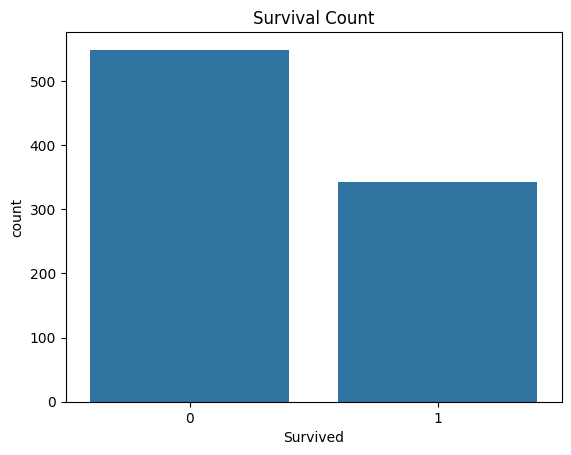

In [54]:
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

Survived column shows how many passengers survived and how many did not survive.

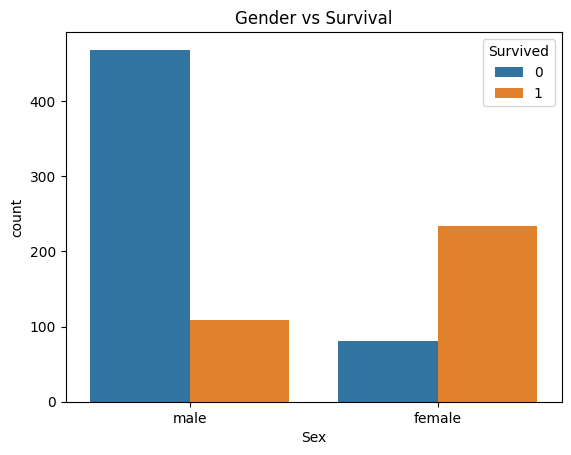

In [55]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Gender vs Survival")
plt.show()

Female passengers had a higher survival rate compared to male passengers.

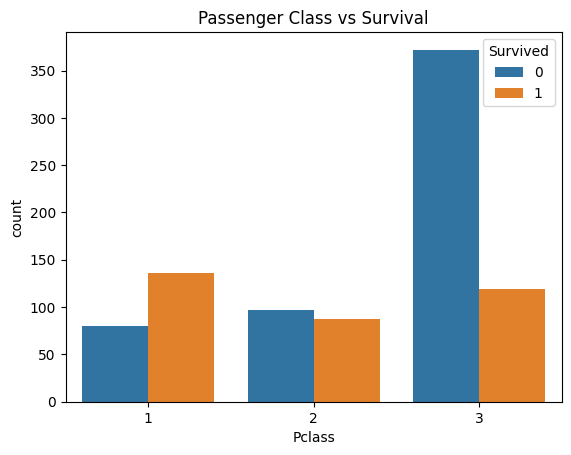

In [56]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Passenger Class vs Survival")
plt.show()

Passengers in higher classes had better survival chances.

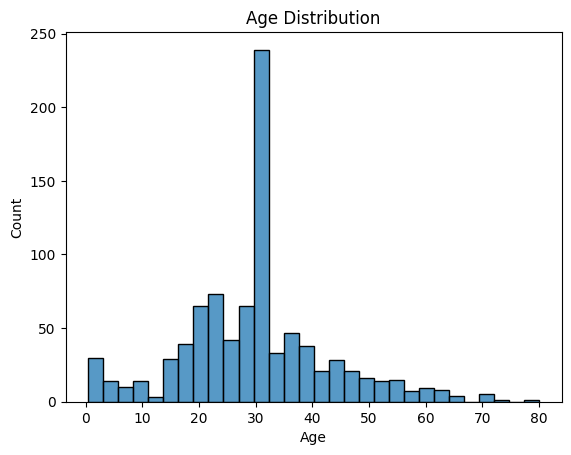

In [57]:
sns.histplot(df['Age'], bins=30)
plt.title("Age Distribution")
plt.show()

Most passengers were between age 20–40.

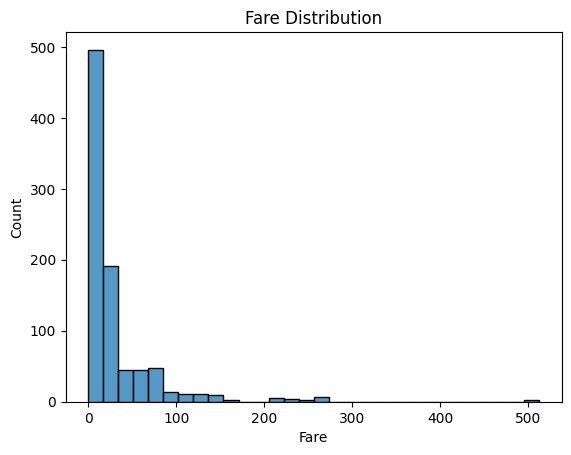

In [58]:
sns.histplot(df['Fare'], bins=30)
plt.title("Fare Distribution")
plt.show()

In [59]:
df['Sex'] = df['Sex'].map({'male':0, 'female':1})

In [60]:
df['Embarked'] = df['Embarked'].map({'S':0, 'C':1, 'Q':2})

In [61]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


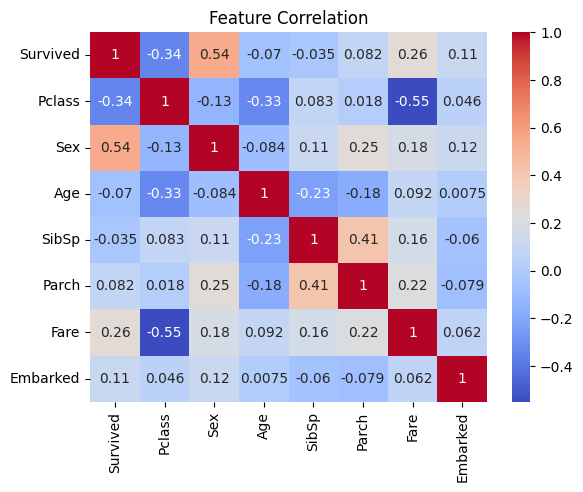

In [62]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

Correlation Analysis

The heatmap shows relationships between different features.
Passenger class, sex, and fare show some correlation with survival.

## Model Implementation
Machine learning models were trained to predict passenger survival.

In [63]:
X = df.drop('Survived', axis=1)
y = df['Survived']

Explanation

X = input features (passenger data)

y = target variable (Survived)

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Explanation:

80% data model will be trained

20% data model will be tested

In [65]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Explanation:

Logistic Regression classification problems ke liye common algorithm hai.

## Model Evaluation
Model performance was evaluated using accuracy and confusion matrix.

In [66]:
pred = model.predict(X_test)

Yeh model se prediction karata hai.

In [67]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.7988826815642458


Accuracy Score of the model

In [68]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)
print(cm)

[[89 16]
 [20 54]]


Confusion Matrix Interpretation

The confusion matrix shows the performance of the model.
The model correctly predicted 89 non-survivals and 54 survivals.
Some predictions were incorrect, such as 16 false positives and 20 false negatives, but overall the model performed well with around 80% accuracy.

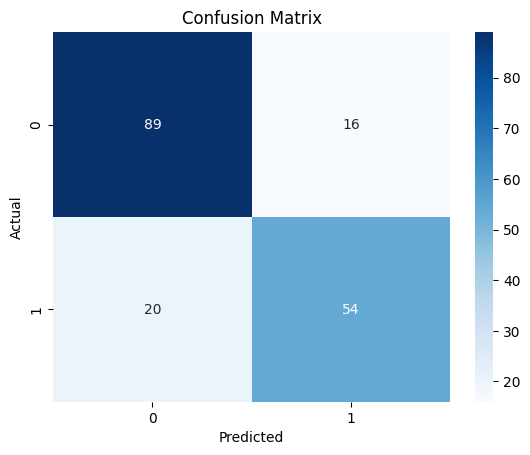

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Conclusion

In this project, the Titanic dataset was analyzed to predict passenger survival using machine learning techniques. Data cleaning, preprocessing, and exploratory data analysis were performed to understand the dataset. A Logistic Regression model was trained and achieved approximately 80% accuracy. The results indicate that features such as passenger class, sex, and fare have significant influence on survival probability.

##Feature Importance

Random Forest:

In [70]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [71]:
importance = rf.feature_importances_

features = X.columns

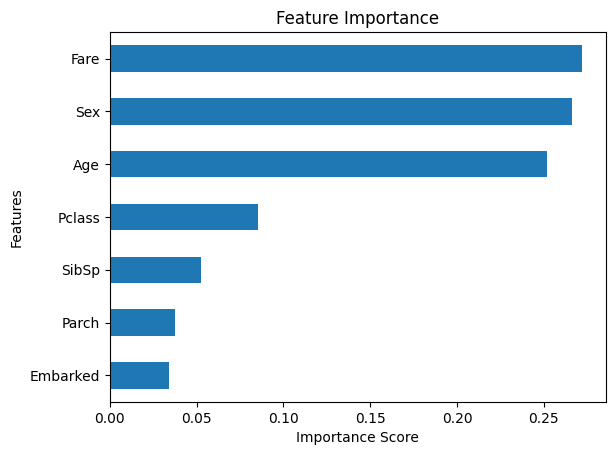

In [72]:
import pandas as pd

feat_importance = pd.Series(importance, index=features)

feat_importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

Feature Importance

The Random Forest model was used to analyze the importance of different features.
The results show that features such as Sex, Pclass, Fare, and Age play a significant role in predicting passenger survival.

In [73]:
rf_pred = rf.predict(X_test)

In [74]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8212290502793296


##Model Comparison

In [75]:
print("Logistic Regression Accuracy:", accuracy)
print("Random Forest Accuracy:", rf_accuracy)

Logistic Regression Accuracy: 0.7988826815642458
Random Forest Accuracy: 0.8212290502793296


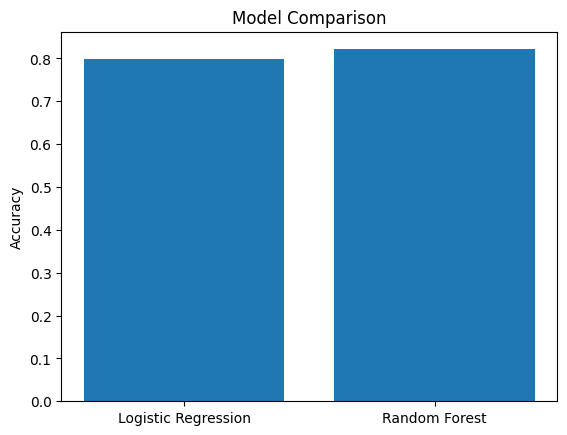

In [76]:
models = ['Logistic Regression', 'Random Forest']
scores = [accuracy, rf_accuracy]

plt.bar(models, scores)

plt.title("Model Comparison")
plt.ylabel("Accuracy")

plt.show()

Model Comparison

Two machine learning models were used in this project: Logistic Regression and Random Forest.
The Random Forest model achieved slightly better accuracy compared to Logistic Regression.
This comparison helps in selecting the most suitable model for prediction.

Conclusion

The analysis shows that features such as passenger class, gender, age, and fare significantly influence survival probability. Machine learning models can effectively predict survival outcomes using these features.